# Spatial Joins and Filter by Location
### by [Kate Vavra-Musser](https://vavramusser.github.io) for the [R Spatial Notebook Series](https://vavramusser.github.io/r-spatial)

## Introduction
In the previous chapter you learned about *geometric binary predicates*, the building blocks of spatial queries.  In this chapter you will learn build on that knowledge to explore *spatial join* and *spatial filtering* functions which build on the *geometric binary predicates*.

### Notebook Goals
This notebook will introduce the [*st_join*](https://rdrr.io/cran/sf/man/st_join.html) and [*st_filter*](https://rdrr.io/cran/sf/man/st_join.html) functions from the [**sf**](https://cran.r-project.org/web/packages/sf/index.html) package.

### ✨ Prerequisites ✨
* Complete [Introduction to sf: Reading, Writing, and Inspecting Vector Data](https://platform.i-guide.io/notebooks/9968babe-22e4-4c3d-98e2-d8b45e9672cd)
* Complete [Working with CRS: Reprojection and Transformation](https://platform.i-guide.io/notebooks/76912ca7-73e4-437e-8ecf-0cb456bd7282)
* Complete [Preparing Vector Data for Analysis](https://platform.i-guide.io/notebooks/44926d85-7f08-4774-a103-a22ff3876cad)
* Complete [IPUMS NHGIS Data Extraction Using ipumsr: Supplemental Exercise 1](https://platform.i-guide.io/notebooks/a74fff96-4db5-430f-b346-958b0c5f7b38)
* Complete [IPUMS NHGIS Data Extraction Using ipumsr: Supplemental Exercise 2](https://platform.i-guide.io/notebooks/bc79eda6-8353-42ea-8cb7-5db70aa6febf)
* Complete [Geometric Binary Predicates: The Building Blocks of Geometric Queries](https://platform.i-guide.io/notebooks/06a40182-91cc-4ed4-befb-7dad6ff99966)

### 💽 Data Used in this Notebook 💽
* United States Populated Places Point Locations Shapefile (*ipums_nhgis_places.shp*)
  * If you worked through [IPUMS NHGIS Data Extraction Using ipumsr: Supplemental Exercise 1](https://platform.i-guide.io/notebooks/a74fff96-4db5-430f-b346-958b0c5f7b38) you should have created and saved a copy of *ipums_nhgis_places.shp* in the final section of the notebook.
  * You can also download a copy of *ipums_nhgis_places.zip* file from [the I-GUIDE platform](https://platform.i-guide.io/datasets/514a645c-fb7e-405e-99de-ac12cf1b143b) or directly from [Kate's GitHub](https://github.com/vavramusser/r-spatial/blob/main/ipums_nhgis_places.zip).  You will need to unzip *ipums_nhgis_places.zip* and extract *ipums_nhgis_places.shp* file to your workspace.
* United States State Boundaries Shapefile (*ipums_nhgis_states.shp*)
  * If you worked through [IPUMS NHGIS Data Extraction Using ipumsr: Supplemental Exercise 2](https://platform.i-guide.io/notebooks/bc79eda6-8353-42ea-8cb7-5db70aa6febf) you should have created and saved a copy of *ipums_nhgis_states.shp* in the final section of the notebook.
  * You can also download a copy of *ipums_nhgis_states.zip* file from [the I-GUIDE platform](https://platform.i-guide.io/datasets/1a5acd50-4741-447a-bf36-2331b39559af) or directly from [Kate's GitHub](https://github.com/vavramusser/r-spatial/blob/main/ipums_nhgis_states.zip).  You will need to unzip *ipums_nhgis_states.zip* and extract *ipums_nhgis_states.shp* file to your workspace.

### Notebook Overview
1. Setup
2. Spatial Joins with `st_join`
3. Filter by Location with `st_filter`

---

## 1. Setup
This notebook requires the following R packages and functions.

##### Required Packages

[**sf**](https://cran.r-project.org/web/packages/sf/index.html) · Support for [simple features](https://r-spatial.github.io/sf/articles/sf1.html), a standardized way to encode spatial vector data - Binds to [*GDAL*](https://gdal.org/en/stable) for reading and writing data, to [*GEOS*](https://libgeos.org) for geometrical operations, and to [*PROJ*](https://proj.org/en/stable) for projection conversions and datum transformations - Uses by default the [*s2*](https://cran.r-project.org/web/packages/s2/index.html) package for spherical geometry operations on ellipsoidal (long/lat) coordinates · This notebook uses the following functions from *sf*.

* [*st_geometry*](https://rdrr.io/cran/sf/man/st_geometry.html) · get, set, replace or rename geometry from an sf object
* [*st_join*](https://rdrr.io/cran/sf/man/st_join.html) · spatial join, spatial filter
  * *st_join* · spatial join
  * *st_filter* · spatial filter
* [*st_read*](https://rdrr.io/cran/sf/man/st_read.html) · read simple features or layers from file or database
* [*valid*](https://rdrr.io/cran/sf/man/valid.html) · check validity or make an invalid geometry valid
  * *st_make_valid* · make an invalid geometry valid
  * *st_is_valid* · check validity

### 1a. Install and Load Required Packages
If you have not already installed the required packages, uncomment and run the code below:

In [17]:
# install.packages("sf")

Load the packages into your workspace.

In [18]:
library(sf)

### 1b. Import, Validate, and Review Data

First we will import two vector datasets to work with using the [*st_read*](https://rdrr.io/cran/sf/man/st_read.html) function from the [**sf**](https://cran.r-project.org/web/packages/sf/index.html) package.  If you worked through [Chapter 3.4.1]() and [Chapter 3.4.2]() you should have saved these files to your workspace and they should be available to work with directly.  If you did not work through these chapters, you can download and import the files to your workspace.

* **United States Populated Places Point Locations** (*ipums_nhgis_places.shp*) downloaded from [IPUMS NHGIS](https://www.nhgis.org) in [Chapter 3.4.1 IPUMS NHGIS Data Extraction Using ipumsr - Supplemental Exercise 1](). 
* **United States State Boundaries** (*ipums_nhgis_states.shp*) downloaded from [IPUMS NHGIS](https://www.nhgis.org) in [Chapter 3.4.2 IPUMS NHGIS Data Extraction Using ipumsr - Supplemental Exercise 2](). 

In [19]:
unzip("ipums_nhgis_places.zip")
unzip("ipums_nhgis_states.zip")

places <- st_read("ipums_nhgis_places.shp")
states <- st_read("ipums_nhgis_states.shp")

Reading layer `ipums_nhgis_places' from data source 
  `C:\Users\vavra\Dropbox\R Spatial\r-spatial\07 Foundational Spatial Analysis\ipums_nhgis_places.shp' 
  using driver `ESRI Shapefile'
Simple feature collection with 29261 features and 8 fields
Geometry type: POINT
Dimension:     XY
Bounding box:  xmin: -6238595 ymin: -1328241 xmax: 2254129 ymax: 4577031
Projected CRS: USA_Contiguous_Albers_Equal_Area_Conic
Reading layer `ipums_nhgis_states' from data source 
  `C:\Users\vavra\Dropbox\R Spatial\r-spatial\07 Foundational Spatial Analysis\ipums_nhgis_states.shp' 
  using driver `ESRI Shapefile'
Simple feature collection with 52 features and 4 fields
Geometry type: MULTIPOLYGON
Dimension:     XY
Bounding box:  xmin: -7115208 ymin: -1685018 xmax: 3321632 ymax: 4591848
Projected CRS: USA_Contiguous_Albers_Equal_Area_Conic


The *places* and *states* feature sets are both projected in [USA Contiguous Albers Equal Area Conic (ESRI code 102003)](https://epsg.io/102003).  We can stick with this project for the notebook and don't need to worry about reprojecting the data.

Let's review the dimensions of the two files.

In [20]:
dim(places)
dim(states)

[1] 29261     9

[1] 52  5

The *places* file includes information on 29,261 populated places and the *states* file includes information on 52 states (50 US states, Washington DC, and Puerto Rico).

Let's take a look at the attributes included in these two files.

In [21]:
head(places)

ERROR while rich displaying an object: Error in loadNamespace(x): there is no package called 'geojsonio'

Traceback:
1. tryCatch(withCallingHandlers({
 .     if (!mime %in% names(repr::mime2repr)) 
 .         stop("No repr_* for mimetype ", mime, " in repr::mime2repr")
 .     rpr <- repr::mime2repr[[mime]](obj)
 .     if (is.null(rpr)) 
 .         return(NULL)
 .     prepare_content(is.raw(rpr), rpr)
 . }, error = error_handler), error = outer_handler)
2. tryCatchList(expr, classes, parentenv, handlers)
3. tryCatchOne(expr, names, parentenv, handlers[[1L]])
4. doTryCatch(return(expr), name, parentenv, handler)
5. withCallingHandlers({
 .     if (!mime %in% names(repr::mime2repr)) 
 .         stop("No repr_* for mimetype ", mime, " in repr::mime2repr")
 .     rpr <- repr::mime2repr[[mime]](obj)
 .     if (is.null(rpr)) 
 .         return(NULL)
 .     prepare_content(is.raw(rpr), rpr)
 . }, error = error_handler)
6. repr::mime2repr[[mime]](obj)
7. repr_geojson.sf(obj)
8. repr_geojson(geo

,GISJOIN,PLACE,STATE,CL8AA1990,CL8AA2000,CL8AA2010,CL8AA2020,NAME,geometry
,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<POINT [m]>
1,G01000100,Abanda CDP,Alabama,177.25,131.68,192,133.00,Abanda,POINT (969164.2 -438781.6)
2,G01000124,Abbeville city,Alabama,3176.41,2987.18,2688,2358.00,Abbeville,POINT (1014139 -605274.1)
3,G01000460,Adamsville city,Alabama,5620.12,5107.32,4522,4353.93,Adamsville,POINT (832255.1 -396765.6)
4,G01000484,Addison town,Alabama,715.01,743.68,758,659.00,Addison,POINT (805355.9 -331802.2)
5,G01000676,Akron town,Alabama,444.66,448.09,356,225.00,Akron,POINT (767096.4 -483924.3)
6,G01000820,Alabaster city,Alabama,15885.55,24415.70,30352,32519.23,Alabaster,POINT (848916.6 -435175.1)


In [22]:
head(states)

ERROR while rich displaying an object: Error in loadNamespace(x): there is no package called 'geojsonio'

Traceback:
1. tryCatch(withCallingHandlers({
 .     if (!mime %in% names(repr::mime2repr)) 
 .         stop("No repr_* for mimetype ", mime, " in repr::mime2repr")
 .     rpr <- repr::mime2repr[[mime]](obj)
 .     if (is.null(rpr)) 
 .         return(NULL)
 .     prepare_content(is.raw(rpr), rpr)
 . }, error = error_handler), error = outer_handler)
2. tryCatchList(expr, classes, parentenv, handlers)
3. tryCatchOne(expr, names, parentenv, handlers[[1L]])
4. doTryCatch(return(expr), name, parentenv, handler)
5. withCallingHandlers({
 .     if (!mime %in% names(repr::mime2repr)) 
 .         stop("No repr_* for mimetype ", mime, " in repr::mime2repr")
 .     rpr <- repr::mime2repr[[mime]](obj)
 .     if (is.null(rpr)) 
 .         return(NULL)
 .     prepare_content(is.raw(rpr), rpr)
 . }, error = error_handler)
6. repr::mime2repr[[mime]](obj)
7. repr_geojson.sf(obj)
8. repr_geojson(geo

,STATEFP10,STUSPS10,NAME10,REGION10,geometry
,<chr>,<chr>,<chr>,<chr>,<MULTIPOLYGON [m]>
1,56,WY,Wyoming,4,MULTIPOLYGON (((-633753.4 8...
2,42,PA,Pennsylvania,1,MULTIPOLYGON (((1743857 454...
3,39,OH,Ohio,2,MULTIPOLYGON (((1073991 515...
4,35,NM,New Mexico,4,MULTIPOLYGON (((-616758.6 -...
5,24,MD,Maryland,3,MULTIPOLYGON (((1738939 231...
6,44,RI,Rhode Island,1,MULTIPOLYGON (((2009795 677...


The two files include the following attributes:

**Places**
* Place Name (*NAME*)
* Detailed Place Name (*PLACE*)
* 1990 Total Population (*CL8AA1990*)
* 2000 Total Population (*CL8AA2000*)
* 2010 Total Population (*CL8AA2010*)
* 2020 Total Population (*CL8AA2020*)
* GIS Join Key (*GISJOIN*)

**States**
* State Name (*NAME10*)
* State FIPS Code (*STATEFP10*)
* State USPS Code (*STUSPS10*)

## 2. Spatial Joins with `st_join`

For this first exercise, we wll perform a spatial join between the places and states files.  The result of this process will be to attach stata attribute information to the *places* object.  In other words, a new version of the *places* file will be produced which includes everything in the original *places* file as well as the information from the *states* file for the corresponding state that the place is in.

In [23]:
places_with_state_data <- st_join(places, states)

Let's take a look at the dimensions and the first few rows of the new *places_with_state_data* object.

In [24]:
dim(places_with_state_data)

[1] 29261    13

In [25]:
head(places_with_state_data)

ERROR while rich displaying an object: Error in loadNamespace(x): there is no package called 'geojsonio'

Traceback:
1. tryCatch(withCallingHandlers({
 .     if (!mime %in% names(repr::mime2repr)) 
 .         stop("No repr_* for mimetype ", mime, " in repr::mime2repr")
 .     rpr <- repr::mime2repr[[mime]](obj)
 .     if (is.null(rpr)) 
 .         return(NULL)
 .     prepare_content(is.raw(rpr), rpr)
 . }, error = error_handler), error = outer_handler)
2. tryCatchList(expr, classes, parentenv, handlers)
3. tryCatchOne(expr, names, parentenv, handlers[[1L]])
4. doTryCatch(return(expr), name, parentenv, handler)
5. withCallingHandlers({
 .     if (!mime %in% names(repr::mime2repr)) 
 .         stop("No repr_* for mimetype ", mime, " in repr::mime2repr")
 .     rpr <- repr::mime2repr[[mime]](obj)
 .     if (is.null(rpr)) 
 .         return(NULL)
 .     prepare_content(is.raw(rpr), rpr)
 . }, error = error_handler)
6. repr::mime2repr[[mime]](obj)
7. repr_geojson.sf(obj)
8. repr_geojson(geo

,GISJOIN,PLACE,STATE,CL8AA1990,CL8AA2000,CL8AA2010,CL8AA2020,NAME,STATEFP10,STUSPS10,NAME10,REGION10,geometry
,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<POINT [m]>
1,G01000100,Abanda CDP,Alabama,177.25,131.68,192,133.00,Abanda,01,AL,Alabama,3,POINT (969164.2 -438781.6)
2,G01000124,Abbeville city,Alabama,3176.41,2987.18,2688,2358.00,Abbeville,01,AL,Alabama,3,POINT (1014139 -605274.1)
3,G01000460,Adamsville city,Alabama,5620.12,5107.32,4522,4353.93,Adamsville,01,AL,Alabama,3,POINT (832255.1 -396765.6)
4,G01000484,Addison town,Alabama,715.01,743.68,758,659.00,Addison,01,AL,Alabama,3,POINT (805355.9 -331802.2)
5,G01000676,Akron town,Alabama,444.66,448.09,356,225.00,Akron,01,AL,Alabama,3,POINT (767096.4 -483924.3)
6,G01000820,Alabaster city,Alabama,15885.55,24415.70,30352,32519.23,Alabaster,01,AL,Alabama,3,POINT (848916.6 -435175.1)


The new *places_with_state_data* object has the same number of rows (29,261) as the original *places* object - each row corresponds to one of the populated places in the data.  However, the number of attributes has increased from 6 to 11.  The additional 5 attributes have been taken from the corresponding state in the *states* object.  Note that the *geometry* column for the new *places_with_state_data* object corresponds to the *places* geometry - that it, point geometries.

We can use this new table to calculate the number of places within each state.

In [26]:
table(places_with_state_data$NAME1)


             Alabama               Alaska              Arizona 
                 579                  343                  451 
            Arkansas           California             Colorado 
                 542                 1522                  458 
         Connecticut             Delaware District of Columbia 
                 142                   75                    1 
             Florida              Georgia               Hawaii 
                 912                  624                  151 
               Idaho             Illinois              Indiana 
                 227                 1367                  682 
                Iowa               Kansas             Kentucky 
                1009                  671                  524 
           Louisiana                Maine             Maryland 
                 473                  131                  518 
       Massachusetts             Michigan            Minnesota 
                 244                  6

## 3. Filter by Location with `st_filter`

For this exercise, we will filter the *places* object to only the populated places located in a particular state.

Before we proceed, we will subset the *states* object to only the state of Michigan and create a new spatial object *michigan*.

In [27]:
michigan <- states[states$NAME10 == "Michigan",]

Next we will us the *st_filter* function from the **sf** package to filter the *places* object to only the populated places which are located in the state of Michigan.

In [28]:
st_crs(michigan)

Coordinate Reference System:
  User input: USA_Contiguous_Albers_Equal_Area_Conic 
  wkt:
PROJCRS["USA_Contiguous_Albers_Equal_Area_Conic",
    BASEGEOGCRS["NAD83",
        DATUM["North American Datum 1983",
            ELLIPSOID["GRS 1980",6378137,298.257222101,
                LENGTHUNIT["metre",1]]],
        PRIMEM["Greenwich",0,
            ANGLEUNIT["Degree",0.0174532925199433]]],
    CONVERSION["USA_Contiguous_Albers_Equal_Area_Conic",
        METHOD["Albers Equal Area",
            ID["EPSG",9822]],
        PARAMETER["Latitude of false origin",37.5,
            ANGLEUNIT["Degree",0.0174532925199433],
            ID["EPSG",8821]],
        PARAMETER["Longitude of false origin",-96,
            ANGLEUNIT["Degree",0.0174532925199433],
            ID["EPSG",8822]],
        PARAMETER["Latitude of 1st standard parallel",29.5,
            ANGLEUNIT["Degree",0.0174532925199433],
            ID["EPSG",8823]],
        PARAMETER["Latitude of 2nd standard parallel",45.5,
            ANGLEUNI

In [29]:
places_within_michigan <- st_filter(places_with_state_data, michigan)

Let's review the results.

In [30]:
dim(places_within_michigan)

[1] 692  13

In [31]:
head(places_within_michigan)

ERROR while rich displaying an object: Error in loadNamespace(x): there is no package called 'geojsonio'

Traceback:
1. tryCatch(withCallingHandlers({
 .     if (!mime %in% names(repr::mime2repr)) 
 .         stop("No repr_* for mimetype ", mime, " in repr::mime2repr")
 .     rpr <- repr::mime2repr[[mime]](obj)
 .     if (is.null(rpr)) 
 .         return(NULL)
 .     prepare_content(is.raw(rpr), rpr)
 . }, error = error_handler), error = outer_handler)
2. tryCatchList(expr, classes, parentenv, handlers)
3. tryCatchOne(expr, names, parentenv, handlers[[1L]])
4. doTryCatch(return(expr), name, parentenv, handler)
5. withCallingHandlers({
 .     if (!mime %in% names(repr::mime2repr)) 
 .         stop("No repr_* for mimetype ", mime, " in repr::mime2repr")
 .     rpr <- repr::mime2repr[[mime]](obj)
 .     if (is.null(rpr)) 
 .         return(NULL)
 .     prepare_content(is.raw(rpr), rpr)
 . }, error = error_handler)
6. repr::mime2repr[[mime]](obj)
7. repr_geojson.sf(obj)
8. repr_geojson(geo

,GISJOIN,PLACE,STATE,CL8AA1990,CL8AA2000,CL8AA2010,CL8AA2020,NAME,STATEFP10,STUSPS10,NAME10,REGION10,geometry
,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<POINT [m]>
1,G26000380,Addison village,Michigan,633.12,627.00,605,573.00,Addison,26,MI,Michigan,2,POINT (956419.9 561319.6)
2,G26000440,Adrian city,Michigan,22182.61,21601.43,21133,20523.57,Adrian,26,MI,Michigan,2,POINT (982979.4 554615.6)
3,G26000480,Advance CDP,Michigan,292.95,357.53,328,340.00,Advance,26,MI,Michigan,2,POINT (855351.1 912772.8)
4,G26000620,Ahmeek village,Michigan,148.00,157.00,146,127.38,Ahmeek,26,MI,Michigan,2,POINT (577703 1117078)
5,G26000700,Akron village,Michigan,421.00,461.00,402,349.00,Akron,26,MI,Michigan,2,POINT (1001258 745216.7)
6,G26000860,Alanson village,Michigan,677.00,785.00,738,778.00,Alanson,26,MI,Michigan,2,POINT (875107.1 940023.6)


The filtering step removed all places which are located outside of Michigan leaving us with a dataset of 692 places.

Let's use the *st_geometry* function from the **sf** package to create a quick plot of the point locations of the places in Michigan.  We will also use the *michigan* object to add the Michigan border to the plot in red.

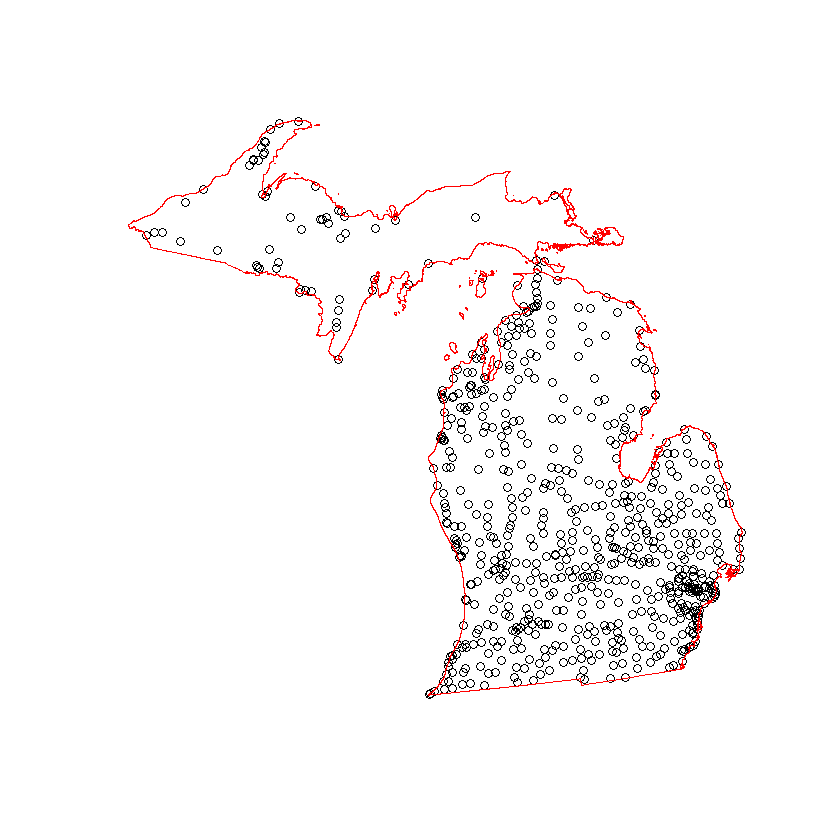

In [32]:
plot(st_geometry(places_within_michigan))
plot(st_geometry(michigan), add = T, border = "red")